In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/ecommerce_master_dataset.csv")
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,31570.0,belo horizonte,SP,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,14840.0,guariba,SP,1.0,credit_card,3.0,179.12


In [3]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [6]:
df["delivery_time_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

df["delivery_time_days"].describe()

count    115037.000000
mean         12.019237
std           9.461440
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_time_days, dtype: float64

In [8]:
df["delivery_delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

In [9]:
df["delivery_time_days"].mean()

np.float64(12.019237288872276)

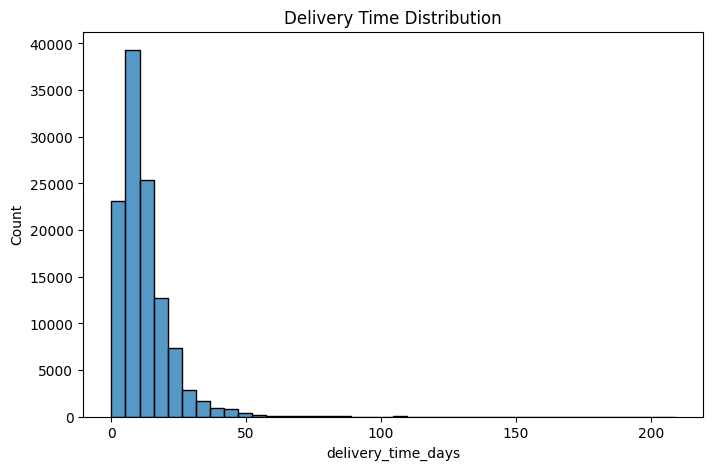

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["delivery_time_days"], bins=40)

plt.title("Delivery Time Distribution")
plt.show()

In [11]:
late_orders = df[df["delivery_delay_days"] > 0]

print("Late deliveries:", late_orders.shape[0])

Late deliveries: 7530


In [12]:
late_rate = late_orders.shape[0] / df.shape[0] * 100

print("Late delivery rate:", late_rate)

Late delivery rate: 6.357971528446223


In [13]:
seller_delivery = df.groupby("seller_id")["delivery_time_days"].mean().sort_values()

seller_delivery.head(10)

seller_id
6561d6bf844e464b4019442692b40e02    1.0
674207551483fec113276b67b0d871ff    1.0
5e063e85d44b0f5c3e6ec3131103a57e    1.0
2c00c85d30361cd2ced2969cffbbffa3    1.0
751e274377499a8503fd6243ad9c56f6    1.0
702835e4b785b67a084280efca355756    1.0
f3511c85f59f8dec53d140501ee8e7a8    1.0
96f7c797de9ca20efbe14545bed63eec    1.0
139157dd4daa45c25b0807ffff348363    1.0
734def04b237117a09321dd6d8f3f2a2    1.5
Name: delivery_time_days, dtype: float64

In [14]:
seller_delivery.tail(10)

seller_id
f5403d3f50089112c4eed37928b7f622   NaN
f543ba3c973276f519d89d59bd46cead   NaN
f7df46c1e0ec44eed5c6726478da4a17   NaN
f9a02f1922d1de564392e656d82b3fda   NaN
f9eda05b67bef472deaddbba84aca289   NaN
fa18c782a4866d313cadab567097f8f1   NaN
fa7ad8ae9bcb2c4493fdf38e96b1d74f   NaN
fc99f99385ae90f66f01733856fb88c9   NaN
fec6912baad85d41729669edd6b4d3b8   NaN
ffcfefa19b08742c5d315f2791395ee5   NaN
Name: delivery_time_days, dtype: float64

In [15]:
state_delivery = df.groupby("customer_state")["delivery_time_days"].mean().sort_values()

state_delivery.head()

customer_state
SP     8.270919
MG    11.497541
PR    11.516530
DF    12.468815
SC    14.498461
Name: delivery_time_days, dtype: float64